# Klassische Baseline-Modelle ohne Deep Learning

## Ueberblick

| Modell | Idee | Aufwand |
|---|---|---|
| **Isolation Forest** | Teilt Daten zufaellig auf -- Anomalien sind leichter zu isolieren | Sehr einfach |
| **One-Class SVM** | Zieht eine Grenze um die normalen Daten | Einfach, aber langsamer |

Beide Modelle werden **nur auf guten Schlaegen** trainiert und sollen dann entscheiden,
ob ein neuer Schlag normal oder eine Anomalie ist.

---

## Was ist ein Isolation Forest?

Idee: Anomalien sind leichter zu isolieren als normale Datenpunkte.

```
Normaler Schlag:   braucht viele zufaellige Splits, um isoliert zu werden
Schlechter Schlag: wird schon nach wenigen Splits isoliert
```

Das Modell baut viele zufaellige Entscheidungsbaeume. Je kuerzer der Pfad
bis zur Isolation, desto hoeher der Anomalie-Score.

---

## Was ist eine One-Class SVM?

Idee: Finde eine Grenze (Hyperebene), die moeglichst alle normalen Datenpunkte einschliesst.

```
Normaler Schlag:   liegt innerhalb der Grenze  --> gut
Schlechter Schlag: liegt ausserhalb der Grenze --> Anomalie
```

Der Parameter `nu` bestimmt, wie streng die Grenze ist:
- kleines `nu` (~0.01) = enge Grenze, wenige False Positives aber mehr verpasste Anomalien
- grosses `nu` (~0.1)  = weitere Grenze, mehr False Positives aber weniger verpasste Anomalien

---

## Warum kein Sequenz-Modell?

Isolation Forest und One-Class SVM arbeiten auf fixen Feature-Vektoren, nicht auf Sequenzen.
Wir verwenden dasselbe Sliding Window wie beim Autoencoder (24 Frames) und **flatten** es:

```
Fenster: (24 Frames x 66 Features)  -->  flatten  -->  1584 Features
```

So sind die Modelle direkt mit dem LSTM Autoencoder vergleichbar.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'
print('Project root:', PROJECT_ROOT)


Project root: /Users/clarabrilke/ML projects/ML-project


## Daten laden

Gleiche Daten wie im Autoencoder-Notebook: beide Datensaetze durch
die koerperrelative Mediapipe-Normalisierung.


In [6]:
df_good = pd.read_csv(NORM_DIR / 'landmarks_all_norm_10fps.csv')
df_bad  = pd.read_csv(NORM_DIR / 'cla-BAD-landmarks-norm_10fps.csv')

exclude = {'phase', 'GOOD', 'BAD'}
feature_cols = [c for c in df_good.columns if c not in exclude]

X_good = df_good[feature_cols].values
X_bad  = df_bad[feature_cols].values

print(f'Gute Schlaege:     {X_good.shape[0]} Frames, {X_good.shape[1]} Features')
print(f'Schlechte Schlaege: {X_bad.shape[0]} Frames, {X_bad.shape[1]} Features')


Gute Schlaege:     11244 Frames, 66 Features
Schlechte Schlaege: 506 Frames, 66 Features


## Sliding Window und Flatten

Gleiche Fenstergroesse wie im Autoencoder (24 Frames, Stride 12).
Danach wird jedes Fenster zu einem 1D-Vektor zusammengefasst (`flatten`).


In [7]:
WINDOW_SIZE = 24
STRIDE      = 12

def create_windows(X, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []
    for start in range(0, len(X) - window_size + 1, stride):
        windows.append(X[start : start + window_size])
    return np.array(windows)

# Sequenzen erstellen und flatten: (n, 24, 66) --> (n, 1584)
X_good_seq = create_windows(X_good).reshape(len(create_windows(X_good)), -1)
X_bad_seq  = create_windows(X_bad).reshape(len(create_windows(X_bad)), -1)

print(f'Gute Sequenzen (flattened):     {X_good_seq.shape}')
print(f'Schlechte Sequenzen (flattened): {X_bad_seq.shape}')

# Train / Validation Split -- zeitlich, kein shuffle
n_train = int(len(X_good_seq) * 0.8)
X_train = X_good_seq[:n_train]
X_val   = X_good_seq[n_train:]

print(f'\nTraining:   {X_train.shape[0]} Sequenzen')
print(f'Validation: {X_val.shape[0]} Sequenzen')
print(f'Schlechte:  {X_bad_seq.shape[0]} Sequenzen')


Gute Sequenzen (flattened):     (936, 1584)
Schlechte Sequenzen (flattened): (41, 1584)

Training:   748 Sequenzen
Validation: 188 Sequenzen
Schlechte:  41 Sequenzen


## Auswertungs-Hilfsfunktion

Beide Modelle geben einen Score aus:
- **Isolation Forest**: negativer Score -- je negativer, desto anomaler
- **One-Class SVM**: negativer Score -- Werte < 0 gelten als Anomalie

Wir normieren alle Scores auf [0, 1] und behandeln hoehere Werte als 'schlechter'.


In [8]:
def evaluate_model(model, X_val, X_bad, model_name):
    scores_val = -model.score_samples(X_val)
    scores_bad = -model.score_samples(X_bad)

    y_scores = np.concatenate([scores_val, scores_bad])
    y_true   = np.array([0] * len(scores_val) + [1] * len(scores_bad))

    threshold = np.percentile(scores_val, 95)
    y_pred    = (y_scores > threshold).astype(int)

    auc = roc_auc_score(y_true, y_scores)
    sep = "=" * 50
    print()
    print(sep)
    print("  " + model_name)
    print(sep)
    print("  ROC-AUC:   " + str(round(auc, 4)))
    print(classification_report(y_true, y_pred, target_names=["Gut", "Schlecht"]))

    return y_true, y_scores, scores_val, scores_bad, threshold, auc


## Isolation Forest

`contamination` gibt an, wie viel Prozent der Trainingsdaten das Modell als Anomalie betrachtet.
Da wir nur auf guten Schlaegen trainieren, setzen wir es sehr klein (0.01 = 1%).


In [9]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=RANDOM_STATE
)
iso_forest.fit(X_train)

y_true_if, scores_if, scores_val_if, scores_bad_if, thresh_if, auc_if = evaluate_model(
    iso_forest, X_val, X_bad_seq, 'Isolation Forest'
)



  Isolation Forest
  ROC-AUC:   0.2547
              precision    recall  f1-score   support

         Gut       0.84      0.95      0.89       188
    Schlecht       0.41      0.17      0.24        41

    accuracy                           0.81       229
   macro avg       0.63      0.56      0.57       229
weighted avg       0.76      0.81      0.77       229



## One-Class SVM

`nu` entspricht dem erwarteten Anteil an Anomalien (aehnlich wie `contamination`).
`rbf`-Kernel erlaubt nicht-lineare Grenzen.

> Hinweis: One-Class SVM ist langsamer als Isolation Forest -- bei grossen Datensaetzen kann das dauern.


In [10]:
oc_svm = OneClassSVM(
    kernel='rbf',
    nu=0.01,
    gamma='scale'
)
oc_svm.fit(X_train)

y_true_svm, scores_svm, scores_val_svm, scores_bad_svm, thresh_svm, auc_svm = evaluate_model(
    oc_svm, X_val, X_bad_seq, 'One-Class SVM'
)



  One-Class SVM
  ROC-AUC:   0.2852
              precision    recall  f1-score   support

         Gut       0.81      0.95      0.87       188
    Schlecht       0.00      0.00      0.00        41

    accuracy                           0.78       229
   macro avg       0.41      0.47      0.44       229
weighted avg       0.67      0.78      0.72       229



## Score-Verteilung

Je weiter die rote Verteilung (schlechte Schlaege) von der blauen (gute Schlaege) getrennt ist,
desto besser trennt das Modell.


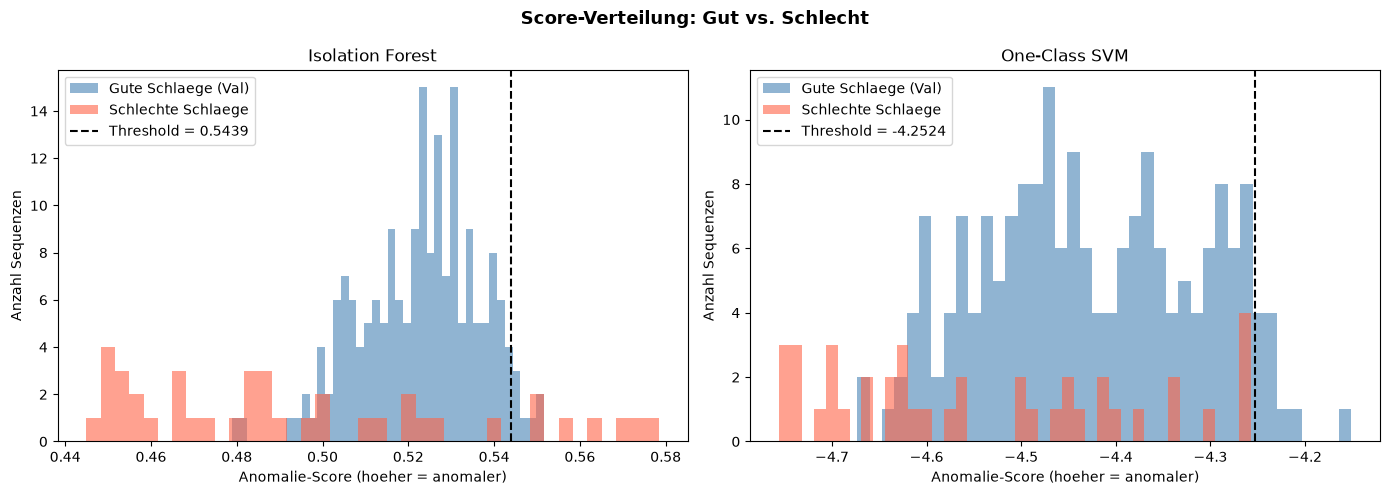

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, sv, sb, thr) in zip(axes, [
    ('Isolation Forest', scores_val_if,  scores_bad_if,  thresh_if),
    ('One-Class SVM',    scores_val_svm, scores_bad_svm, thresh_svm),
]):
    ax.hist(sv, bins=40, alpha=0.6, color='steelblue', label='Gute Schlaege (Val)')
    ax.hist(sb, bins=40, alpha=0.6, color='tomato',    label='Schlechte Schlaege')
    ax.axvline(thr, color='black', linestyle='--', label=f'Threshold = {thr:.4f}')
    ax.set_title(name)
    ax.set_xlabel('Anomalie-Score (hoeher = anomaler)')
    ax.set_ylabel('Anzahl Sequenzen')
    ax.legend()

plt.suptitle('Score-Verteilung: Gut vs. Schlecht', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


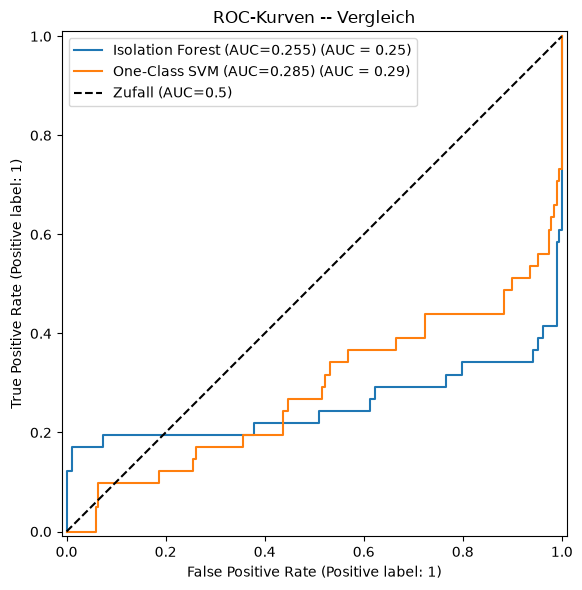

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_true_if, scores_if,
    name=f'Isolation Forest (AUC={auc_if:.3f})',
    ax=ax
)
RocCurveDisplay.from_predictions(
    y_true_svm, scores_svm,
    name=f'One-Class SVM (AUC={auc_svm:.3f})',
    ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', label='Zufall (AUC=0.5)')
ax.set_title('ROC-Kurven -- Vergleich')
ax.legend()
plt.tight_layout()
plt.show()


## Vergleich aller Modelle

*(Werte nach Ausfuehren eintragen)*

| Modell | ROC-AUC | Recall (Schlecht) | Precision (Schlecht) | F1 (Schlecht) |
|---|---|---|---|---|
| LSTM Autoencoder | 0.55 | 0.37 | 0.38 | 0.38 |
| Isolation Forest | -- | -- | -- | -- |
| One-Class SVM | -- | -- | -- | -- |

### Was bedeuten diese Modelle als Baseline?

- ROC-AUC nahe 0.5 = das Modell ist nicht besser als zufaelliges Raten
- ROC-AUC > 0.7 = das Modell trennt gut und gut genug, um als Baseline zu dienen
- ROC-AUC > 0.85 = starkes Modell

Ein komplexeres Modell in Ordner 3 sollte alle diese Baselines uebertreffen.
Wenn ein einfaches Modell schon sehr gut funktioniert, lohnt sich Deep Learning moeglicherweise nicht.
